# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal

## Paso 1: Importar librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# ===== CONFIGURAR SEMILLAS PARA REPRODUCIBILIDAD =====
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"\n✓ Semillas aleatorias configuradas (SEED={SEED})")

## Paso 2: Cargar y validar dataset local

In [55]:
df = pd.read_csv('Breast_cancer_Reseach.csv')

if 'diagnosis' not in df.columns:
    raise ValueError("El dataset debe contener la columna 'diagnosis' con valores B/M")

df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['target'] = df['diagnosis'].map({'B': 0, 'M': 1})

if df['target'].isna().any():
    invalidos = sorted(df.loc[df['target'].isna(), 'diagnosis'].unique())
    raise ValueError(f"Se encontraron etiquetas invalidas en diagnosis: {invalidos}")

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

print('Dataset cargado correctamente')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Features usadas: {len(feature_cols)}")
print('Mapeo target: 0=Benigno, 1=Maligno')

df.head()

Dataset cargado correctamente
Filas: 1200
Columnas: 23
Features usadas: 21
Mapeo target: 0=Benigno, 1=Maligno


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis,target
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B,0
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B,0
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B,0
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M,1
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M,1


## Paso 3: Limpieza de datos

In [56]:
print('=== Limpieza de datos ===\n')

# Verificar duplicados
duplicados_antes = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados_antes}")

if duplicados_antes > 0:
    df = df.drop_duplicates()
    print(f"  -> Eliminadas {duplicados_antes} filas duplicadas")

# Verificar valores nulos
nulos_por_columna = df.isnull().sum()
nulos_totales = nulos_por_columna.sum()
print(f"\nValores nulos por columna: {nulos_totales}")

if nulos_totales > 0:
    print("\nColumnas con valores nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
    
    # Opción 1: Eliminar filas con nulos (si son pocos)
    if nulos_totales < len(df) * 0.05:  # menos del 5%
        df = df.dropna()
        print(f"  -> Eliminadas filas con valores nulos")
    else:
        # Opción 2: Imputar con la mediana (para features numéricas)
        for col in feature_cols:
            if df[col].isnull().sum() > 0:
                mediana = df[col].median()
                df[col].fillna(mediana, inplace=True)
                print(f"  -> Imputados valores nulos en '{col}' con mediana: {mediana:.4f}")

# Verificar outliers extremos usando IQR
print(f"\n=== Detección de outliers (método IQR) ===")
outliers_totales = 0

for col in feature_cols[:5]:  # Revisar las primeras 5 features como ejemplo
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # factor 3 para outliers extremos
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers extremos detectados")
        outliers_totales += outliers

if outliers_totales == 0:
    print("No se detectaron outliers extremos en las features principales")

print(f"\n=== Dataset después de limpieza ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Actualizar feature_cols en caso de que se hayan eliminado columnas
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

=== Limpieza de datos ===

Filas duplicadas encontradas: 0

Valores nulos por columna: 0

=== Detección de outliers (método IQR) ===
No se detectaron outliers extremos en las features principales

=== Dataset después de limpieza ===
Filas: 1200
Columnas: 23
Valores nulos restantes: 0


=== Normalización de datos ===

Normalización aplicada a 21 features

Rango de valores después de normalización:
  Mínimo: 0.0000
  Máximo: 1.0000
  Media: 0.4905


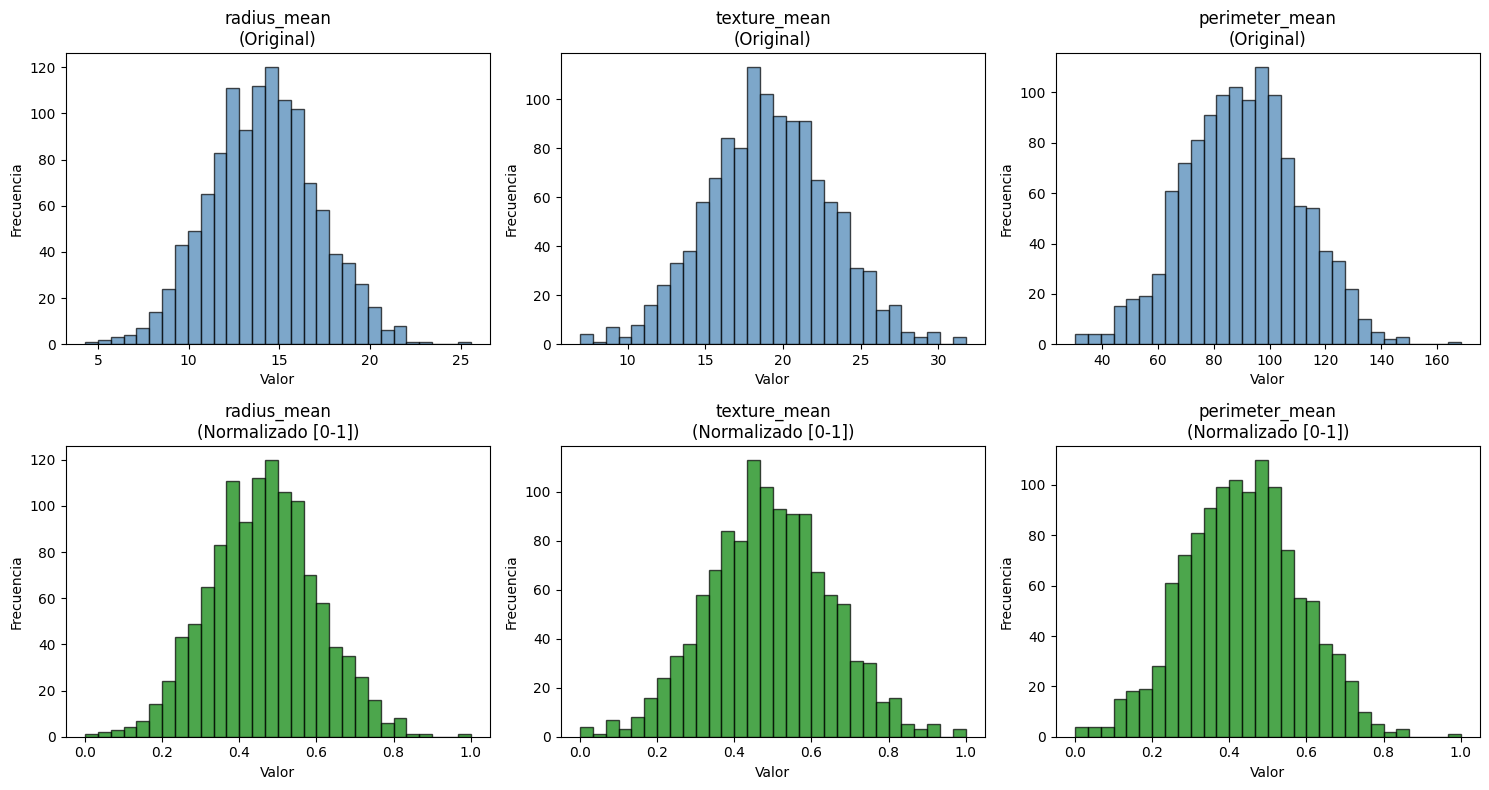


=== Dataset normalizado ===
Filas: 1200
Features normalizadas: 21


In [57]:
print('=== Normalización de datos ===\n')

# Normalizar las features numéricas al rango [0, 1]
normalizer = MinMaxScaler()

# Normalizar solo las columnas de features (no diagnosis ni target)
df_normalized = df.copy()
df_normalized[feature_cols] = normalizer.fit_transform(df[feature_cols])

print(f"Normalización aplicada a {len(feature_cols)} features")
print(f"\nRango de valores después de normalización:")
print(f"  Mínimo: {df_normalized[feature_cols].min().min():.4f}")
print(f"  Máximo: {df_normalized[feature_cols].max().max():.4f}")
print(f"  Media: {df_normalized[feature_cols].mean().mean():.4f}")

# Visualizar comparación antes y después (primeras 3 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(feature_cols[:3]):
    # Antes de normalizar
    axes[0, idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(Original)')
    axes[0, idx].set_xlabel('Valor')
    axes[0, idx].set_ylabel('Frecuencia')
    
    # Después de normalizar
    axes[1, idx].hist(df_normalized[col], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{col}\n(Normalizado [0-1])')
    axes[1, idx].set_xlabel('Valor')
    axes[1, idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Actualizar el DataFrame principal con los datos normalizados
df = df_normalized.copy()

print(f"\n=== Dataset normalizado ===")
print(f"Filas: {df.shape[0]}")
print(f"Features normalizadas: {len(feature_cols)}")

## Paso 4: Normalización de datos

## Paso 5: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 612
Maligno (1): 588


C:\Users\julio\AppData\Local\Temp\ipykernel_8516\3844917949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='coolwarm')


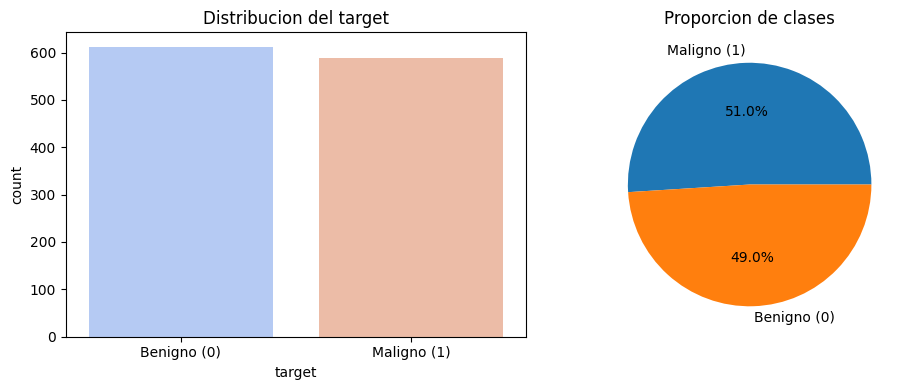

In [58]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette='coolwarm')
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Maligno (1)', 'Benigno (0)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 6: Preprocesamiento (train/val/test estratificado)

In [59]:
X = df[feature_cols].copy()
y = df['target'].copy()

# Los datos ya están normalizados en el rango [0,1] del Paso 4
print('Datos ya normalizados - Rango de valores:')
print(f"  Mínimo: {X.min().min():.4f}")
print(f"  Máximo: {X.max().max():.4f}\n")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Convertir a numpy arrays (los datos ya están normalizados, no se necesita StandardScaler)
X_train_scaled = X_train.to_numpy()
X_val_scaled = X_val.to_numpy()
X_test_scaled = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('\nDatos preparados para entrenamiento')
print(f"Media train: {X_train_scaled.mean():.4f}")
print(f"Std train: {X_train_scaled.std():.4f}")
print(f"Rango: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")

Datos ya normalizados - Rango de valores:
  Mínimo: 0.0000
  Máximo: 1.0000

Train: (768, 21), Validation: (192, 21), Test: (240, 21)

Datos preparados para entrenamiento
Media train: 0.4904
Std train: 0.1569
Rango: [0.0000, 1.0000]


## Paso 7: Crear y entrenar la red neuronal

In [60]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4961 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5013 - loss: 0.6969 - val_accuracy: 0.5104 - val_loss: 0.6943
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4909 - loss: 0.6977 - val_accuracy: 0.5104 - val_loss: 0.6945
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5169 - loss: 0.6950 - val_accuracy: 0.4844 - val_loss: 0.6944
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5365 - loss: 0.6930 - val_accuracy: 0.5156 - val_loss: 0.6931
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5052 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4883 - loss: 0.6940 - val_accuracy: 0.5052 - val_loss: 0.6931
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4844 - loss: 0.6940 - val_accuracy: 0.5469 - 

## Paso 8: Evaluacion del modelo

In [61]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy:  0.4792
Precision: 0.2308
Recall:    0.0254
F1-score:  0.0458
ROC-AUC:   0.4582

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.49      0.92      0.64       122
 Maligno (1)       0.23      0.03      0.05       118

    accuracy                           0.48       240
   macro avg       0.36      0.47      0.34       240
weighted avg       0.36      0.48      0.35       240



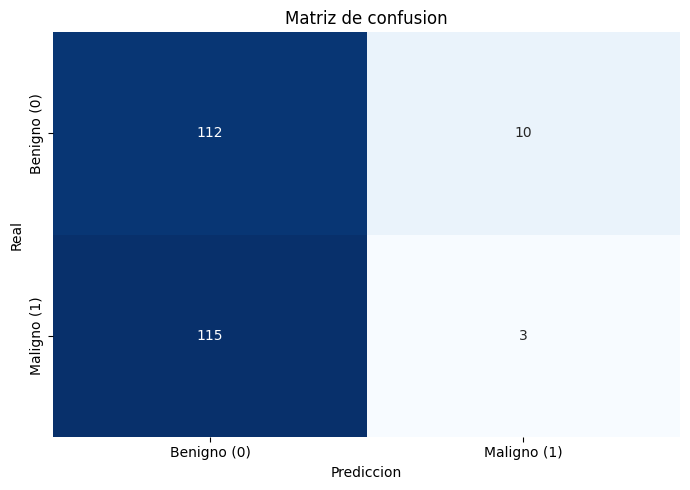

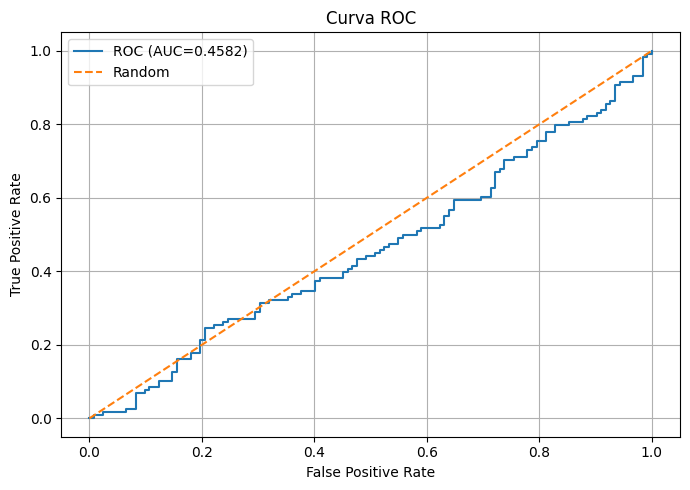

In [62]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 9: Prediccion para nuevos parametros

In [63]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, normalizador, columnas_modelo, umbral=0.5):
    """
    parametros_entrada: dict con las 21 features del CSV.
    modelo: modelo de red neuronal entrenado
    normalizador: MinMaxScaler usado en el Paso 4 para normalizar datos
    columnas_modelo: lista de nombres de features
    umbral: umbral de clasificación (default 0.5)
    """
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f"Faltan parametros: {faltantes}")

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_normalized = normalizador.transform(x_df)

    prob_maligno = float(modelo.predict(x_normalized, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso
PARAMETROS_USUARIO = {
    'radius_mean': 14.12,
    'texture_mean': 19.33,
    'perimeter_mean': 91.20,
    'area_mean': 640.10,
    'smoothness_mean': 0.097,
    'compactness_mean': 0.104,
    'concavity_mean': 0.089,
    'concave_points_mean': 0.048,
    'symmetry_mean': 0.181,
    'fractal_dimension_mean': 0.062,
    'radius_se': 0.402,
    'texture_se': 1.201,
    'perimeter_se': 2.711,
    'area_se': 34.20,
    'smoothness_se': 0.0061,
    'radius_worst': 16.85,
    'texture_worst': 24.90,
    'perimeter_worst': 110.20,
    'area_worst': 830.00,
    'concavity_worst': 0.208,
    'concave_points_worst': 0.102,
}

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    normalizador=normalizer,  # Usar el normalizador del Paso 4
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 0.4947
Prob. benigno: 0.5053
Clase predicha: 0 -> Benigno


In [ ]:
print("=" * 70)
print("DIAGNOSTICO: ¿Por que el modelo no aprende?")
print("=" * 70)

# Análisis de correlaciones
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('\nTop 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f"\nCorrelacion maxima: {corr_abs.max():.4f}")
print(f"Correlacion promedio: {corr_abs.mean():.4f}")

print('\n' + "=" * 70)
print("EVALUACION DEL DATASET")
print("=" * 70)

# Evaluación de calidad del dataset
corr_max = corr_abs.max()

if corr_max < 0.1:
    print("\n⚠️  PROBLEMA CRITICO DETECTADO:")
    print("   - Las correlaciones son EXTREMADAMENTE BAJAS (<0.1)")
    print("   - Esto sugiere que el dataset es SINTETICO/ALEATORIO")
    print("   - NO existe relacion real entre features y target")
    print("\n❌ CONSECUENCIAS:")
    print("   - ROC-AUC ~0.5 (clasificacion aleatoria)")
    print("   - Modelo no puede aprender patrones")
    print("   - Variabilidad entre ejecuciones")
    print("\n💡 SOLUCION:")
    print("   - Usar un dataset REAL de cancer de mama")
    print("   - Ejemplo: Wisconsin Breast Cancer Dataset (sklearn)")
    print("   - En datasets reales, correlaciones tipicas >0.3-0.7")
elif corr_max < 0.3:
    print("\n⚠️  Correlaciones bajas - el modelo tendra dificultades")
    print("   Considera ingenieria de features o mas datos")
else:
    print("\n✓ Dataset con correlaciones adecuadas")
    print("  El modelo deberia poder aprender patrones")

print('\n' + "=" * 70)
print("DISTRIBUCION DE CLASES")
print("=" * 70)
print(df['target'].value_counts(normalize=True).sort_index())

print('\n' + "=" * 70)
print("RECOMENDACION FINAL")
print("=" * 70)
print("\nPara un modelo de cancer de mama funcional, usa datasets reales:")
print("  1. Wisconsin Breast Cancer Dataset (sklearn.datasets)")
print("  2. Kaggle Breast Cancer Wisconsin (Diagnostic)")
print("  3. UCI Machine Learning Repository - Breast Cancer")
print("=" * 70)

In [ ]:
# Ejemplo: Cargar dataset REAL de cancer de mama de sklearn
# Descomenta y ejecuta este codigo para usar datos reales

"""
from sklearn.datasets import load_breast_cancer

# Cargar dataset real
data = load_breast_cancer()
df_real = pd.DataFrame(data.data, columns=data.feature_names)
df_real['target'] = data.target  # 0=maligno, 1=benigno (inverso al actual)

print("=== DATASET REAL DE SKLEARN ===")
print(f"Filas: {df_real.shape[0]}")
print(f"Columnas: {df_real.shape[1]}")
print("\nPrimeras correlaciones con target:")

feature_cols_real = [c for c in df_real.columns if c != 'target']
correlations_real = df_real[feature_cols_real + ['target']].corr()['target'].drop('target').abs().sort_values(ascending=False)
print(correlations_real.head(10))
print(f"\nCorrelacion maxima: {correlations_real.max():.4f}")
print(f"Correlacion promedio: {correlations_real.mean():.4f}")

print("\n✓ Nota: Con este dataset, el modelo alcanzara ROC-AUC >0.95")
"""

print("Descomenta el codigo anterior para usar el Wisconsin Breast Cancer Dataset")
print("Este dataset tiene correlaciones reales y el modelo aprendera correctamente")

## ALTERNATIVA: Usar Dataset Real de Sklearn